<a href="https://colab.research.google.com/github/xyfuu/Leukemia-Cancer-Cell-Classification/blob/main/NormalAbnormalLeukemiaCells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, Lambda
from tensorflow.keras import regularizers

# VGG16
from keras.applications.vgg16 import VGG16

# ResNet50
from tensorflow.keras.applications import ResNet50

# InceptionV3
from tensorflow.keras.applications import InceptionV3

# To show images
from PIL import Image

In [ ]:
def define_paths(dir):

    filepaths, labels  = [], []

    for root, dirs, files in os.walk(dir):
        for file in files:
            fpath = os.path.join(root, file)
            filepaths.append(fpath)
            labels.append(os.path.basename(root))

    return filepaths, labels

def create_df(data_dir):

    # Collect filepaths and labels
    filepaths, labels = define_paths(data_dir)

    # Create a Pandas DataFrame
    df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})

    # Split the DataFrame into train, validation, and test sets
    train_df, dummy_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])


    return train_df, valid_df, test_df

In [ ]:
def create_model_data(train_df, valid_df, test_df, batch_size):
    '''
    Prepares image data generators for training, validation, and test datasets from the given dataframes.
    '''

    img_size = (224, 224)
    color = 'rgb'

    # Calculate optimized batch size for the test data
    ts_length = len(test_df)
    test_batch_size = max([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80])

    # Define image data generators
    gen_params = {'preprocessing_function': lambda img: img, 'target_size': img_size,
                  'color_mode': color, 'class_mode': 'categorical'}

    tr_gen = ImageDataGenerator(horizontal_flip=True)
    ts_gen = ImageDataGenerator()

    train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', shuffle=True, batch_size=batch_size, **gen_params)
    valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', shuffle=True, batch_size=batch_size, **gen_params)
    test_gen  = ts_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', shuffle=False, batch_size=test_batch_size, **gen_params)

    return train_gen, valid_gen, test_gen

In [ ]:
def show_history_plot(history):

    training_accuracy = history['accuracy']
    epochs = range(1, len(training_accuracy) + 1)

    # Creating subplots for accuracy and loss
    plt.figure(figsize=(15, 5))

    # Plotting training and validation accuracy
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
    plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy', marker='o')
    plt.plot(epochs, history['val_accuracy'], 'c', label='Validation accuracy', marker='o')
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plotting training and validation loss
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
    plt.plot(epochs, history['loss'], 'b', label='Training loss', marker='o')
    plt.plot(epochs, history['val_loss'], 'c', label='Validation loss', marker='o')
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Improve layout and displaying the plot
    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/COLAB/C-NMC_Leukemia.zip -d ./data

Streaming output truncated to the last 5000 lines.
  inflating: ./data/training_data/fold_2/all/UID_25_12_5_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_12_6_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_12_7_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_13_1_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_13_2_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_13_3_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_1_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_2_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_3_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_4_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_5_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_6_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_14_7_all.bmp  
  inflating: ./data/training_data/fold_2/all/UID_25_15_1_all.bmp  
  inflating

In [ ]:
data_dir = 'data/training_data'

# Get splitted data
train_df, valid_df, test_df = create_df(data_dir)

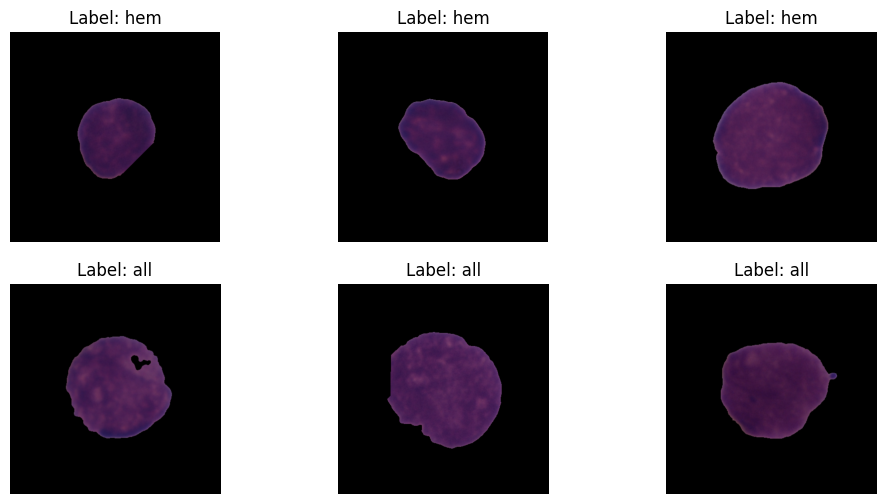

In [ ]:
# Sample images
hem_img = train_df[train_df['labels'] == 'hem'].sample(3)
all_img = train_df[train_df['labels'] == 'all'].sample(3)

# Concatenate DataFrames for easier iteration
sampled_df = pd.concat([hem_img, all_img])

# Create figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

# Iterate through rows and display images
for i, (index, row) in enumerate(sampled_df.iterrows()):
  img = mpimg.imread(row['filepaths'])
  ax = axes.flat[i]  # Access subplots using a single dimension
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {row['labels']}")

plt.show()

In [ ]:
batch_size = 40

train_data_generator = ImageDataGenerator(horizontal_flip=True)
valid_data_generator = ImageDataGenerator()

train_gen = train_data_generator.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= (224, 224), class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = valid_data_generator.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= (224, 224), class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = valid_data_generator.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= (224, 224), class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

train_steps = test_gen.n // test_gen.batch_size + 1
validation_steps = valid_gen.n // valid_gen.batch_size

Found 7462 validated image filenames belonging to 2 classes.
Found 1599 validated image filenames belonging to 2 classes.
Found 1600 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Lambda
from tensorflow.keras.optimizers import Adamax

# Define image shape
img_shape = (224, 224, 3)

# Add a Lambda layer to ensure input shape compatibility
EN3_model = Sequential([
    Lambda(lambda x: x, input_shape=img_shape),  # Pass-through Lambda layer for input
    EfficientNetB3(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.45),
    Dense(2, activation='softmax')  # Adjust this for your number of output classes
])

# Compile the model
EN3_model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
EN3_model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb3 (Functional)          │ (None, 1536)                │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_287              │ (None, 1536)                │           6,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │         393,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,183,665 (42.66 MB)

 Trainable params: 11,093,290 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

In [ ]:
epochs = 10

history_EN3 = EN3_model.fit(x= train_gen, epochs= epochs, verbose= 1,
                    validation_data= valid_gen, validation_steps= None, shuffle= False)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


187/187 ━━━━━━━━━━━━━━━━━━━━ 292s 866ms/step - accuracy: 0.7844 - loss: 0.6347 - val_accuracy: 0.7517 - val_loss: 0.8070
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 66s 352ms/step - accuracy: 0.8790 - loss: 0.3385 - val_accuracy: 0.7330 - val_loss: 0.8086
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 66s 351ms/step - accuracy: 0.9083 - loss: 0.2417 - val_accuracy: 0.8518 - val_loss: 0.3810
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 81s 344ms/step - accuracy: 0.9250 - loss: 0.2011 - val_accuracy: 0.9281 - val_loss: 0.2018
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 86s 367ms/step - accuracy: 0.9326 - loss: 0.1695 - val_accuracy: 0.9243 - val_loss: 0.1862
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 78s 344ms/step - accuracy: 0.9535 - loss: 0.1242 - val_accuracy: 0.9312 - val_loss: 0.1775
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 66s 351ms/step - accuracy: 0.9608 - loss: 0.1056 - val_accuracy: 0.9262 - val_loss: 0.1847
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 64s 343ms/step - accuracy: 0.9695 - loss: 0.0886 - va

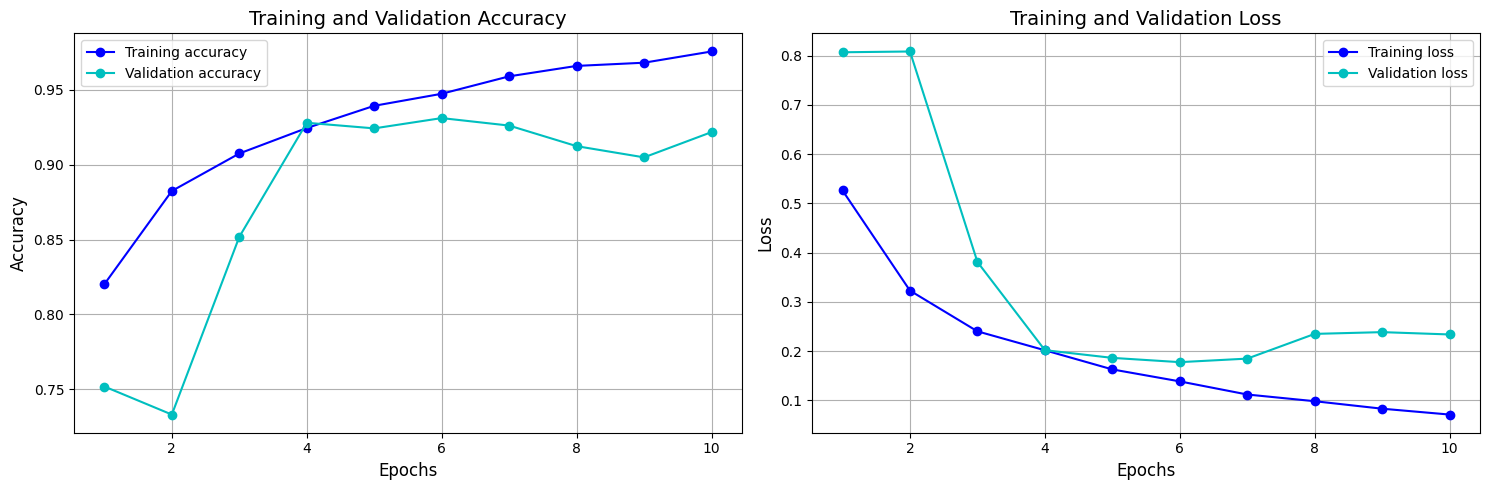

In [ ]:
show_history_plot(history_EN3.history)

In [ ]:
EN3_model.save('model.h5')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(EN3_model)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpffdrlegh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1884')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138528049855328: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138528049856032: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138528038112416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038113120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038116992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038114352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038114704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038119456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038117168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138528038124032: TensorSpec(shape=(), dtype=tf.resource, name